Number of cities: 100
Coordinates shape: (100, 2)
Adjacency shape: (100, 100)
Node feature shape: (100, 3)
2-opt iteration: 1 distance: 8.7244835
2-opt iteration: 2 distance: 8.466965
2-opt iteration: 3 distance: 8.466965

Pseudo route distance: 8.466965
Edge label shape: (100, 100)
Node embedding shape: (100, 16)
Epoch: 0 Loss: 0.6925201263918724
Epoch: 100 Loss: 0.627904125246791
Epoch: 200 Loss: 0.5749596891386192
Epoch: 300 Loss: 0.5302965039718521
Epoch: 400 Loss: 0.49240119609357047
Edge importance shape: (100, 100)
2-opt iteration: 1 distance: 9.46776
2-opt iteration: 2 distance: 8.875946
2-opt iteration: 3 distance: 8.7112465
2-opt iteration: 4 distance: 8.69735
2-opt iteration: 5 distance: 8.69735

Final Route:
[0, 92, 60, 84, 59, 89, 33, 30, 98, 62, 99, 14, 73, 32, 51, 54, 94, 65, 5, 13, 15, 31, 36, 7, 69, 61, 28, 81, 72, 77, 80, 44, 35, 26, 74, 46, 85, 12, 37, 56, 41, 48, 43, 66, 9, 58, 87, 23, 1, 21, 40, 82, 83, 10, 97, 49, 78, 50, 90, 38, 25, 79, 19, 95, 91, 39, 70, 96, 20

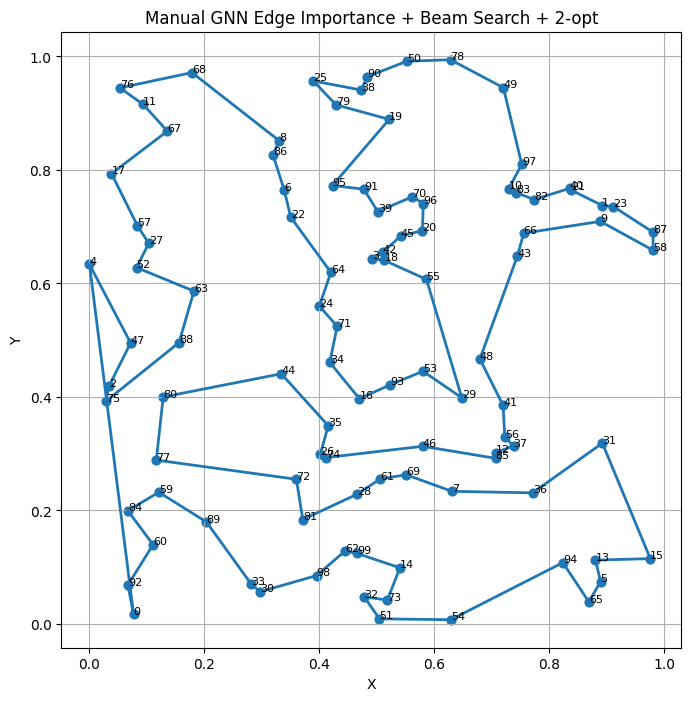

In [1]:
#ManualGNN+BS+1-pseudoinput
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("large.csv", header=None)

coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)
print("Coordinates shape:", coords.shape)

def compute_distance_matrix(coords):
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt(np.sum(diff ** 2, axis=-1))
    return D

distance_matrix = compute_distance_matrix(coords)

K = 10

A = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(num_nodes):
    nearest = np.argsort(distance_matrix[i])[1:K+1]

    for j in nearest:
        A[i][j] = 1
        A[j][i] = 1

A = A + np.eye(num_nodes, dtype=np.float32)

print("Adjacency shape:", A.shape)


degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))

A_hat = D_inv_sqrt @ A @ D_inv_sqrt


avg_distance = np.mean(distance_matrix, axis=1).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)

X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

num_features = X.shape[1]

print("Node feature shape:", X.shape)


def nearest_neighbor_route(D, start=0):
    n = len(D)
    visited = set([start])
    route = [start]
    current = start

    while len(route) < n:
        best_node = None
        best_dist = float("inf")

        for j in range(n):
            if j not in visited:
                if D[current][j] < best_dist:
                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)
        visited.add(best_node)
        current = best_node

    route.append(start)

    return route

def route_distance(route, D):
    total = 0

    for i in range(len(route) - 1):
        total += D[route[i]][route[i+1]]

    return total


def two_opt(route, D, max_iter=100):
    best = route[:]
    best_distance = route_distance(best, D)

    improved = True
    iteration = 0

    while improved and iteration < max_iter:
        improved = False
        iteration += 1

        for i in range(1, len(best) - 2):
            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]
                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:
                    best = new_route
                    best_distance = new_distance
                    improved = True

        print("2-opt iteration:", iteration, "distance:", best_distance)

    return best

initial_route = nearest_neighbor_route(distance_matrix, start=0)
pseudo_route = two_opt(initial_route, distance_matrix, max_iter=20)

print("\nPseudo route distance:", route_distance(pseudo_route, distance_matrix))



edge_labels = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(len(pseudo_route) - 1):
    u = pseudo_route[i]
    v = pseudo_route[i + 1]

    edge_labels[u][v] = 1
    edge_labels[v][u] = 1

print("Edge label shape:", edge_labels.shape)


np.random.seed(42)

hidden_dim = 32
embedding_dim = 16

W1 = np.random.randn(num_features, hidden_dim) * 0.1
W2 = np.random.randn(hidden_dim, embedding_dim) * 0.1

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

H1 = relu(A_hat @ X @ W1)
H2 = relu(A_hat @ H1 @ W2)

print("Node embedding shape:", H2.shape)


edge_features = []
edge_targets = []

for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            feature_ij = np.concatenate([
                H2[i],
                H2[j],
                [distance_matrix[i][j]]
            ])

            edge_features.append(feature_ij)
            edge_targets.append(edge_labels[i][j])

edge_features = np.array(edge_features, dtype=np.float32)
edge_targets = np.array(edge_targets, dtype=np.float32).reshape(-1, 1)


edge_features[:, -1] = (
    edge_features[:, -1] - edge_features[:, -1].mean()
) / (edge_features[:, -1].std() + 1e-8)

input_edge_dim = edge_features.shape[1]

W_edge = np.random.randn(input_edge_dim, 1) * 0.1

learning_rate = 0.1
epochs = 500

for epoch in range(epochs):

    logits = edge_features @ W_edge
    preds = sigmoid(logits)

    loss = -np.mean(
        edge_targets * np.log(preds + 1e-8)
        + (1 - edge_targets) * np.log(1 - preds + 1e-8)
    )

    grad_logits = preds - edge_targets
    grad_W = edge_features.T @ grad_logits / len(edge_features)

    W_edge -= learning_rate * grad_W

    if epoch % 100 == 0:
        print("Epoch:", epoch, "Loss:", loss)


edge_importance = np.zeros((num_nodes, num_nodes), dtype=np.float32)

index = 0

for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            edge_importance[i][j] = preds[index][0]
            index += 1

np.fill_diagonal(edge_importance, 0)

print("Edge importance shape:", edge_importance.shape)



epsilon = 1e-6

learned_cost = distance_matrix / (edge_importance + epsilon)


np.fill_diagonal(learned_cost, 1e9)



def beam_search_route(cost_matrix, start=0, beam_width=5):
    n = len(cost_matrix)

    beams = [
        ([start], 0.0, set([start]))
    ]

    while True:

        new_beams = []

        for route, cost, visited in beams:

            if len(route) == n:
                final_cost = cost + cost_matrix[route[-1]][start]
                final_route = route + [start]
                new_beams.append((final_route, final_cost, visited))
                continue

            current = route[-1]

            for nxt in range(n):

                if nxt not in visited:
                    new_route = route + [nxt]
                    new_cost = cost + cost_matrix[current][nxt]
                    new_visited = set(visited)
                    new_visited.add(nxt)

                    new_beams.append((new_route, new_cost, new_visited))

        new_beams = sorted(new_beams, key=lambda x: x[1])

        beams = new_beams[:beam_width]

        if len(beams[0][0]) == n + 1:
            break

    return beams[0][0]

gnn_route = beam_search_route(
    learned_cost,
    start=0,
    beam_width=5
)


final_route = two_opt(
    gnn_route,
    distance_matrix,
    max_iter=20
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(route_distance(final_route, distance_matrix))


route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(coords[:, 0], coords[:, 1], s=40)

plt.plot(route_coords[:, 0], route_coords[:, 1], linewidth=2)

for i in range(num_nodes):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=8)

plt.title("Manual GNN Edge Importance + Beam Search + 2-opt")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

Number of cities: 100
2-opt iteration: 1 distance: 8.7244835
2-opt iteration: 2 distance: 8.466965
2-opt iteration: 3 distance: 8.466965

NN + 2-opt Distance:
8.466965
Node embedding shape: (100, 16)
Epoch: 0 Loss: 0.6925201263918724
Epoch: 100 Loss: 0.627904125246791
Epoch: 200 Loss: 0.5749596891386192
Epoch: 300 Loss: 0.5302965039718521
Epoch: 400 Loss: 0.49240119609357047
GA generation: 0 learned cost: 131.98933
GA generation: 50 learned cost: 96.708405
GA generation: 100 learned cost: 94.19977
GA generation: 150 learned cost: 84.402466

GA Route Distance before 2-opt:
30.210772
2-opt iteration: 1 distance: 10.48129
2-opt iteration: 2 distance: 8.995218
2-opt iteration: 3 distance: 8.606262
2-opt iteration: 4 distance: 8.573688
2-opt iteration: 5 distance: 8.573688

Final Route:
[0, 92, 60, 84, 59, 77, 75, 2, 47, 4, 17, 67, 11, 76, 68, 86, 8, 25, 79, 19, 38, 90, 50, 78, 49, 97, 10, 83, 43, 66, 82, 40, 21, 9, 1, 23, 87, 58, 41, 56, 37, 12, 85, 36, 31, 15, 5, 65, 13, 94, 7, 69, 61, 28

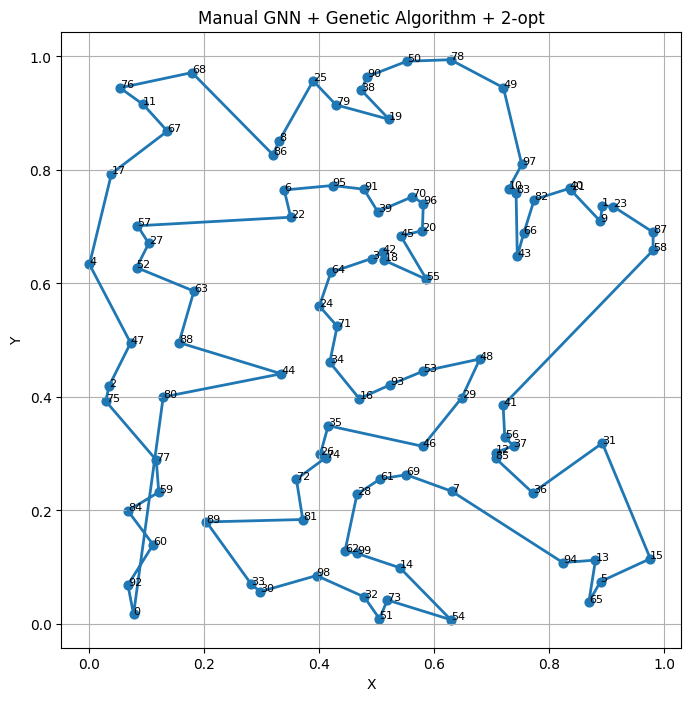

In [2]:
#ManualGNN+GA+1-pseudoinput

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("large.csv", header=None)
coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)


def compute_distance_matrix(coords):
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt(np.sum(diff ** 2, axis=-1))
    return D

distance_matrix = compute_distance_matrix(coords)


K = 10

A = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(num_nodes):
    nearest = np.argsort(distance_matrix[i])[1:K+1]

    for j in nearest:
        A[i][j] = 1
        A[j][i] = 1

A = A + np.eye(num_nodes, dtype=np.float32)

degree = np.sum(A, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
A_hat = D_inv_sqrt @ A @ D_inv_sqrt


avg_distance = np.mean(distance_matrix, axis=1).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)

X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

num_features = X.shape[1]


def route_distance(route, D):
    total = 0

    for i in range(len(route) - 1):
        total += D[route[i]][route[i+1]]

    return total


def nearest_neighbor_route(D, start=0):
    n = len(D)
    visited = set([start])
    route = [start]
    current = start

    while len(route) < n:
        best_node = None
        best_dist = float("inf")

        for j in range(n):
            if j not in visited:
                if D[current][j] < best_dist:
                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)
        visited.add(best_node)
        current = best_node

    route.append(start)

    return route



def two_opt(route, D, max_iter=50):
    best = route[:]
    best_distance = route_distance(best, D)

    improved = True
    iteration = 0

    while improved and iteration < max_iter:
        improved = False
        iteration += 1

        for i in range(1, len(best) - 2):
            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]
                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:
                    best = new_route
                    best_distance = new_distance
                    improved = True

        print("2-opt iteration:", iteration, "distance:", best_distance)

    return best



start_city = 0

initial_route = nearest_neighbor_route(
    distance_matrix,
    start=start_city
)

pseudo_route = two_opt(
    initial_route,
    distance_matrix,
    max_iter=20
)

print("\nNN + 2-opt Distance:")
print(route_distance(pseudo_route, distance_matrix))



edge_labels = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(len(pseudo_route) - 1):
    u = pseudo_route[i]
    v = pseudo_route[i + 1]

    edge_labels[u][v] = 1
    edge_labels[v][u] = 1



np.random.seed(42)

hidden_dim = 32
embedding_dim = 16

W1 = np.random.randn(num_features, hidden_dim) * 0.1
W2 = np.random.randn(hidden_dim, embedding_dim) * 0.1

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

H1 = relu(A_hat @ X @ W1)
H2 = relu(A_hat @ H1 @ W2)

print("Node embedding shape:", H2.shape)



edge_features = []
edge_targets = []

for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            feature_ij = np.concatenate([
                H2[i],
                H2[j],
                [distance_matrix[i][j]]
            ])

            edge_features.append(feature_ij)
            edge_targets.append(edge_labels[i][j])

edge_features = np.array(edge_features, dtype=np.float32)
edge_targets = np.array(edge_targets, dtype=np.float32).reshape(-1, 1)

edge_features[:, -1] = (
    edge_features[:, -1] - edge_features[:, -1].mean()
) / (edge_features[:, -1].std() + 1e-8)

W_edge = np.random.randn(edge_features.shape[1], 1) * 0.1

learning_rate = 0.1
epochs = 500

for epoch in range(epochs):

    logits = edge_features @ W_edge
    preds = sigmoid(logits)

    loss = -np.mean(
        edge_targets * np.log(preds + 1e-8)
        + (1 - edge_targets) * np.log(1 - preds + 1e-8)
    )

    grad_logits = preds - edge_targets
    grad_W = edge_features.T @ grad_logits / len(edge_features)

    W_edge -= learning_rate * grad_W

    if epoch % 100 == 0:
        print("Epoch:", epoch, "Loss:", loss)



edge_importance = np.zeros((num_nodes, num_nodes), dtype=np.float32)

index = 0

for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            edge_importance[i][j] = preds[index][0]
            index += 1

np.fill_diagonal(edge_importance, 0)



epsilon = 1e-6

learned_cost = distance_matrix / (edge_importance + epsilon)

np.fill_diagonal(learned_cost, 1e9)


# GENETIC ALGORITHM
def create_individual(num_nodes, start):
    cities = [i for i in range(num_nodes) if i != start]
    np.random.shuffle(cities)
    return cities

def individual_to_route(individual, start):
    return [start] + individual + [start]

def fitness(individual, cost_matrix, start):
    route = individual_to_route(individual, start)
    return route_distance(route, cost_matrix)

def tournament_selection(population, cost_matrix, start, k=3):
    selected = np.random.choice(len(population), k, replace=False)

    best = None
    best_score = float("inf")

    for idx in selected:
        score = fitness(population[idx], cost_matrix, start)

        if score < best_score:
            best_score = score
            best = population[idx]

    return best.copy()

def order_crossover(parent1, parent2):
    n = len(parent1)

    a, b = sorted(np.random.choice(n, 2, replace=False))

    child = [-1] * n

    child[a:b] = parent1[a:b]

    pointer = b

    for city in parent2:
        if city not in child:
            if pointer >= n:
                pointer = 0

            child[pointer] = city
            pointer += 1

    return child

def mutate(individual, mutation_rate=0.1):
    if np.random.rand() < mutation_rate:
        i, j = np.random.choice(len(individual), 2, replace=False)
        individual[i], individual[j] = individual[j], individual[i]

    return individual

def genetic_algorithm(
    cost_matrix,
    start=0,
    population_size=80,
    generations=200,
    mutation_rate=0.2
):
    population = [
        create_individual(num_nodes, start)
        for _ in range(population_size)
    ]

    best_individual = None
    best_cost = float("inf")

    for gen in range(generations):

        new_population = []

        for _ in range(population_size):

            parent1 = tournament_selection(
                population,
                cost_matrix,
                start
            )

            parent2 = tournament_selection(
                population,
                cost_matrix,
                start
            )

            child = order_crossover(parent1, parent2)

            child = mutate(
                child,
                mutation_rate
            )

            new_population.append(child)

        population = new_population

        for individual in population:
            current_cost = fitness(
                individual,
                cost_matrix,
                start
            )

            if current_cost < best_cost:
                best_cost = current_cost
                best_individual = individual.copy()

        if gen % 50 == 0:
            print("GA generation:", gen, "learned cost:", best_cost)

    best_route = individual_to_route(
        best_individual,
        start
    )

    return best_route


ga_route = genetic_algorithm(
    learned_cost,
    start=start_city,
    population_size=80,
    generations=200,
    mutation_rate=0.2
)

print("\nGA Route Distance before 2-opt:")
print(route_distance(ga_route, distance_matrix))



final_route = two_opt(
    ga_route,
    distance_matrix,
    max_iter=30
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(route_distance(final_route, distance_matrix))



print("\n================ COMPARISON ================")

print("NN + 2-opt Distance:")
print(route_distance(pseudo_route, distance_matrix))

print("GNN + GA + 2-opt Distance:")
print(route_distance(final_route, distance_matrix))




route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(coords[:, 0], coords[:, 1], s=40)

plt.plot(route_coords[:, 0], route_coords[:, 1], linewidth=2)

for i in range(num_nodes):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=8)

plt.title("Manual GNN + Genetic Algorithm + 2-opt")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

Number of cities: 100
Coordinates shape: (100, 2)
Distance matrix shape: (100, 100)
Adjacency shape: (100, 100)
Normalized adjacency shape: (100, 100)
Node feature shape: (100, 3)
Start city: 0 | pseudo route distance: 8.466965
Start city: 1 | pseudo route distance: 7.880031
Start city: 2 | pseudo route distance: 8.030834
Start city: 3 | pseudo route distance: 8.162343
Start city: 4 | pseudo route distance: 7.9357576
Start city: 5 | pseudo route distance: 8.250826
Start city: 6 | pseudo route distance: 7.9867287
Start city: 7 | pseudo route distance: 8.37647
Start city: 8 | pseudo route distance: 8.047838
Start city: 9 | pseudo route distance: 7.9274263
Start city: 10 | pseudo route distance: 8.216549
Start city: 11 | pseudo route distance: 8.084217
Start city: 12 | pseudo route distance: 8.034227
Start city: 13 | pseudo route distance: 9.044995
Start city: 14 | pseudo route distance: 8.309969
Start city: 15 | pseudo route distance: 8.396156
Start city: 16 | pseudo route distance: 8.00

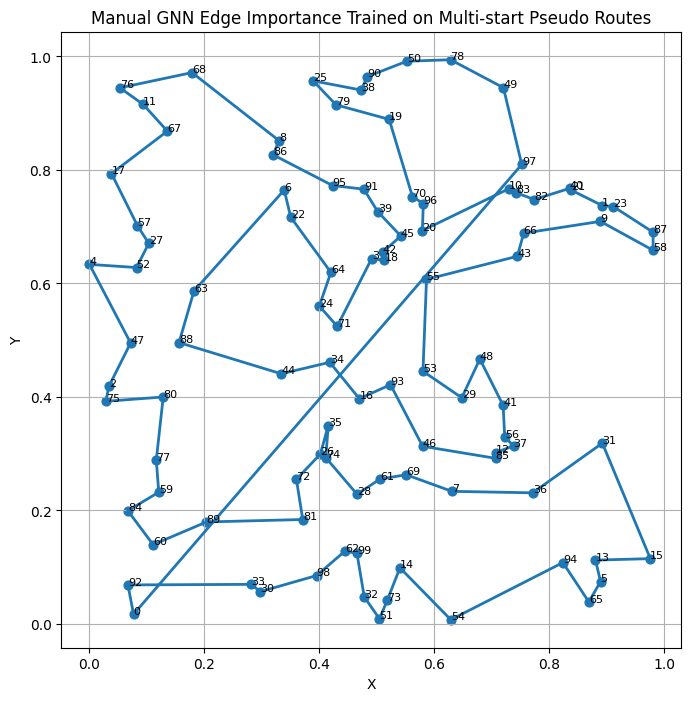

In [3]:
#ManualGNN+BS+30-pseudoinput

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("large.csv", header=None)

coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)
print("Coordinates shape:", coords.shape)


def compute_distance_matrix(coords):
    num_cities = len(coords)

    distance_matrix = np.zeros(
        (num_cities, num_cities),
        dtype=np.float32
    )

    for i in range(num_cities):
        for j in range(num_cities):

            x1 = coords[i][0]
            y1 = coords[i][1]

            x2 = coords[j][0]
            y2 = coords[j][1]

            distance = np.sqrt(
                (x1 - x2) ** 2 +
                (y1 - y2) ** 2
            )

            distance_matrix[i][j] = distance

    return distance_matrix


distance_matrix = compute_distance_matrix(coords)

print("Distance matrix shape:", distance_matrix.shape)


K = 10

A = np.zeros(
    (num_nodes, num_nodes),
    dtype=np.float32
)

for i in range(num_nodes):

    nearest = np.argsort(distance_matrix[i])[1:K + 1]

    for j in nearest:

        A[i][j] = 1
        A[j][i] = 1


A = A + np.eye(
    num_nodes,
    dtype=np.float32
)

print("Adjacency shape:", A.shape)


degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(
    1.0 / np.sqrt(degree + 1e-8)
)

A_hat = D_inv_sqrt @ A @ D_inv_sqrt

print("Normalized adjacency shape:", A_hat.shape)



avg_distance = np.mean(
    distance_matrix,
    axis=1
).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)

X = (
    X - X.mean(axis=0)
) / (
    X.std(axis=0) + 1e-8
)

num_features = X.shape[1]

print("Node feature shape:", X.shape)



def nearest_neighbor_route(D, start=0):

    n = len(D)

    visited = set([start])

    route = [start]

    current = start

    while len(route) < n:

        best_node = None
        best_dist = float("inf")

        for j in range(n):

            if j not in visited:

                if D[current][j] < best_dist:

                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)

        visited.add(best_node)

        current = best_node

    route.append(start)

    return route


def route_distance(route, D):

    total = 0

    for i in range(len(route) - 1):

        total += D[route[i]][route[i + 1]]

    return total



def two_opt(route, D, max_iter=50):

    best = route[:]

    best_distance = route_distance(best, D)

    improved = True

    iteration = 0

    while improved and iteration < max_iter:

        improved = False

        iteration += 1

        for i in range(1, len(best) - 2):

            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]

                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:

                    best = new_route

                    best_distance = new_distance

                    improved = True

    return best



NUM_STARTS = min(num_nodes, 30)

start_cities = list(range(NUM_STARTS))

pseudo_routes = []

pseudo_distances = []

for start in start_cities:

    initial_route = nearest_neighbor_route(
        distance_matrix,
        start=start
    )

    pseudo_route = two_opt(
        initial_route,
        distance_matrix,
        max_iter=20
    )

    pseudo_routes.append(pseudo_route)

    dist = route_distance(
        pseudo_route,
        distance_matrix
    )

    pseudo_distances.append(dist)

    print(
        "Start city:",
        start,
        "| pseudo route distance:",
        dist
    )

print("\nTotal pseudo routes generated:", len(pseudo_routes))

best_route_index = np.argmin(pseudo_distances)

best_pseudo_route = pseudo_routes[best_route_index]

best_pseudo_distance = pseudo_distances[best_route_index]

print("\nBest pseudo route start city:", start_cities[best_route_index])
print("Best pseudo route distance:", best_pseudo_distance)


all_edge_labels = []

for pseudo_route in pseudo_routes:

    edge_labels = np.zeros(
        (num_nodes, num_nodes),
        dtype=np.float32
    )

    for i in range(len(pseudo_route) - 1):

        u = pseudo_route[i]
        v = pseudo_route[i + 1]

        edge_labels[u][v] = 1
        edge_labels[v][u] = 1

    all_edge_labels.append(edge_labels)

all_edge_labels = np.array(
    all_edge_labels,
    dtype=np.float32
)

print("\nAll edge labels shape:", all_edge_labels.shape)



np.random.seed(42)

hidden_dim = 32

embedding_dim = 16

W1 = np.random.randn(
    num_features,
    hidden_dim
) * 0.1

W2 = np.random.randn(
    hidden_dim,
    embedding_dim
) * 0.1


def relu(x):
    return np.maximum(0, x)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


H1 = relu(
    A_hat @ X @ W1
)

H2 = relu(
    A_hat @ H1 @ W2
)

print("\nNode embedding shape:", H2.shape)


edge_features = []

edge_targets = []

for route_id in range(len(pseudo_routes)):

    edge_labels = all_edge_labels[route_id]

    for i in range(num_nodes):

        for j in range(num_nodes):

            if i != j:

                feature_ij = np.concatenate([
                    H2[i],
                    H2[j],
                    [distance_matrix[i][j]]
                ])

                edge_features.append(feature_ij)

                edge_targets.append(edge_labels[i][j])

edge_features = np.array(
    edge_features,
    dtype=np.float32
)

edge_targets = np.array(
    edge_targets,
    dtype=np.float32
).reshape(-1, 1)

print("\nEdge features shape:", edge_features.shape)
print("Edge targets shape:", edge_targets.shape)


edge_distance_mean = edge_features[:, -1].mean()

edge_distance_std = edge_features[:, -1].std()

edge_features[:, -1] = (
    edge_features[:, -1] - edge_distance_mean
) / (
    edge_distance_std + 1e-8
)

input_edge_dim = edge_features.shape[1]

print("\nInput edge dimension:", input_edge_dim)


W_edge = np.random.randn(
    input_edge_dim,
    1
) * 0.1

learning_rate = 0.1

epochs = 500

for epoch in range(epochs):

    logits = edge_features @ W_edge

    preds = sigmoid(logits)

    loss = -np.mean(
        edge_targets * np.log(preds + 1e-8)
        +
        (1 - edge_targets) * np.log(1 - preds + 1e-8)
    )

    grad_logits = preds - edge_targets

    grad_W = (
        edge_features.T @ grad_logits
    ) / len(edge_features)

    W_edge -= learning_rate * grad_W

    if epoch % 100 == 0:

        print(
            "Epoch:",
            epoch,
            "Loss:",
            loss
        )



single_edge_features = []

for i in range(num_nodes):

    for j in range(num_nodes):

        if i != j:

            feature_ij = np.concatenate([
                H2[i],
                H2[j],
                [distance_matrix[i][j]]
            ])

            single_edge_features.append(feature_ij)

single_edge_features = np.array(
    single_edge_features,
    dtype=np.float32
)

single_edge_features[:, -1] = (
    single_edge_features[:, -1] - edge_distance_mean
) / (
    edge_distance_std + 1e-8
)

final_logits = single_edge_features @ W_edge

final_preds = sigmoid(final_logits)

edge_importance = np.zeros(
    (num_nodes, num_nodes),
    dtype=np.float32
)

index = 0

for i in range(num_nodes):

    for j in range(num_nodes):

        if i != j:

            edge_importance[i][j] = final_preds[index][0]

            index += 1

np.fill_diagonal(edge_importance, 0)

print("\nFinal edge importance shape:", edge_importance.shape)


distance_norm = distance_matrix / (
    distance_matrix.max() + 1e-8
)

alpha = 0.7
beta = 0.3

learned_cost = (
    alpha * distance_norm
    +
    beta * (1 - edge_importance)
)

np.fill_diagonal(learned_cost, 1e9)

print("Learned cost shape:", learned_cost.shape)



def beam_search_route(cost_matrix, start=0, beam_width=5):

    n = len(cost_matrix)

    beams = [
        ([start], 0.0, set([start]))
    ]

    while True:

        new_beams = []

        for route, cost, visited in beams:

            if len(route) == n:

                final_cost = cost + cost_matrix[route[-1]][start]

                final_route = route + [start]

                new_beams.append(
                    (final_route, final_cost, visited)
                )

                continue

            current = route[-1]

            for nxt in range(n):

                if nxt not in visited:

                    new_route = route + [nxt]

                    new_cost = cost + cost_matrix[current][nxt]

                    new_visited = set(visited)

                    new_visited.add(nxt)

                    new_beams.append(
                        (new_route, new_cost, new_visited)
                    )

        new_beams = sorted(
            new_beams,
            key=lambda x: x[1]
        )

        beams = new_beams[:beam_width]

        if len(beams[0][0]) == n + 1:

            break

    return beams[0][0]




start_city = 0

gnn_route = beam_search_route(
    learned_cost,
    start=start_city,
    beam_width=5
)

print("\nGNN beam-search route distance before final 2-opt:")
print(
    route_distance(
        gnn_route,
        distance_matrix
    )
)


final_route = two_opt(
    gnn_route,
    distance_matrix,
    max_iter=20
)

final_distance = route_distance(
    final_route,
    distance_matrix
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(final_distance)



print("\n================ COMPARISON ================")


selected_start_index = start_cities.index(start_city)


same_start_pseudo_route = pseudo_routes[selected_start_index]

same_start_pseudo_distance = pseudo_distances[selected_start_index]

print("Selected start city:")
print(start_city)

print("\nPseudo route distance for this start city:")
print(same_start_pseudo_distance)

print("\nGNN + Beam Search + 2-opt final distance:")
print(final_distance)

if final_distance < same_start_pseudo_distance:

    improvement = (
        (same_start_pseudo_distance - final_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nGNN final route is better than pseudo route of same start city.")
    print("Improvement (%):", improvement)

elif final_distance > same_start_pseudo_distance:

    worsening = (
        (final_distance - same_start_pseudo_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nPseudo route of same start city is better.")
    print("GNN final route is worse by (%):", worsening)

else:

    print("\nBoth routes have the same distance.")


route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=40
)

plt.plot(
    route_coords[:, 0],
    route_coords[:, 1],
    linewidth=2
)

for i in range(num_nodes):

    plt.text(
        coords[i, 0],
        coords[i, 1],
        str(i),
        fontsize=8
    )

plt.title(
    "Manual GNN Edge Importance Trained on Multi-start Pseudo Routes"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()

Number of cities: 100
Coordinates shape: (100, 2)
Distance matrix shape: (100, 100)
Adjacency shape: (100, 100)
Normalized adjacency shape: (100, 100)
Node feature shape: (100, 3)
Start city: 0 | pseudo route distance: 8.466965
Start city: 1 | pseudo route distance: 7.880031
Start city: 2 | pseudo route distance: 8.030834
Start city: 3 | pseudo route distance: 8.162343
Start city: 4 | pseudo route distance: 7.9357576
Start city: 5 | pseudo route distance: 8.250826
Start city: 6 | pseudo route distance: 7.9867287
Start city: 7 | pseudo route distance: 8.37647
Start city: 8 | pseudo route distance: 8.047838
Start city: 9 | pseudo route distance: 7.9274263
Start city: 10 | pseudo route distance: 8.216549
Start city: 11 | pseudo route distance: 8.084217
Start city: 12 | pseudo route distance: 8.034227
Start city: 13 | pseudo route distance: 9.044995
Start city: 14 | pseudo route distance: 8.309969
Start city: 15 | pseudo route distance: 8.396156
Start city: 16 | pseudo route distance: 8.00

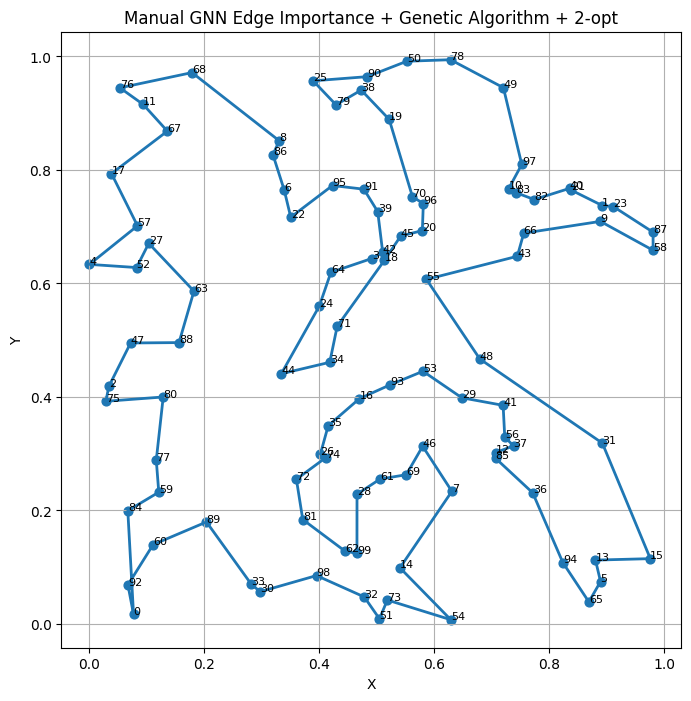

In [4]:
#ManualGNN+GA+30-pseudoinput


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("large.csv", header=None)

coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)
print("Coordinates shape:", coords.shape)


def compute_distance_matrix(coords):
    num_cities = len(coords)

    distance_matrix = np.zeros(
        (num_cities, num_cities),
        dtype=np.float32
    )

    for i in range(num_cities):
        for j in range(num_cities):

            x1 = coords[i][0]
            y1 = coords[i][1]

            x2 = coords[j][0]
            y2 = coords[j][1]

            distance = np.sqrt(
                (x1 - x2) ** 2 +
                (y1 - y2) ** 2
            )

            distance_matrix[i][j] = distance

    return distance_matrix


distance_matrix = compute_distance_matrix(coords)

print("Distance matrix shape:", distance_matrix.shape)


K = 10

A = np.zeros(
    (num_nodes, num_nodes),
    dtype=np.float32
)

for i in range(num_nodes):

    nearest = np.argsort(distance_matrix[i])[1:K + 1]

    for j in nearest:

        A[i][j] = 1
        A[j][i] = 1

# Add self-loops
A = A + np.eye(
    num_nodes,
    dtype=np.float32
)

print("Adjacency shape:", A.shape)


degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(
    1.0 / np.sqrt(degree + 1e-8)
)

A_hat = D_inv_sqrt @ A @ D_inv_sqrt

print("Normalized adjacency shape:", A_hat.shape)


avg_distance = np.mean(
    distance_matrix,
    axis=1
).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)

X = (
    X - X.mean(axis=0)
) / (
    X.std(axis=0) + 1e-8
)

num_features = X.shape[1]

print("Node feature shape:", X.shape)


def nearest_neighbor_route(D, start=0):

    n = len(D)

    visited = set([start])

    route = [start]

    current = start

    while len(route) < n:

        best_node = None
        best_dist = float("inf")

        for j in range(n):

            if j not in visited:

                if D[current][j] < best_dist:

                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)

        visited.add(best_node)

        current = best_node

    route.append(start)

    return route



def route_distance(route, D):

    total = 0

    for i in range(len(route) - 1):

        total += D[route[i]][route[i + 1]]

    return total


def two_opt(route, D, max_iter=50):

    best = route[:]

    best_distance = route_distance(best, D)

    improved = True

    iteration = 0

    while improved and iteration < max_iter:

        improved = False

        iteration += 1

        for i in range(1, len(best) - 2):

            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]

                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:

                    best = new_route

                    best_distance = new_distance

                    improved = True

    return best



NUM_STARTS = min(num_nodes, 30)

start_cities = list(range(NUM_STARTS))

pseudo_routes = []

pseudo_distances = []

for start in start_cities:

    initial_route = nearest_neighbor_route(
        distance_matrix,
        start=start
    )

    pseudo_route = two_opt(
        initial_route,
        distance_matrix,
        max_iter=20
    )

    pseudo_routes.append(pseudo_route)

    dist = route_distance(
        pseudo_route,
        distance_matrix
    )

    pseudo_distances.append(dist)

    print(
        "Start city:",
        start,
        "| pseudo route distance:",
        dist
    )

print("\nTotal pseudo routes generated:", len(pseudo_routes))

best_route_index = np.argmin(pseudo_distances)

best_pseudo_route = pseudo_routes[best_route_index]

best_pseudo_distance = pseudo_distances[best_route_index]

print("\nBest pseudo route start city:", start_cities[best_route_index])
print("Best pseudo route distance:", best_pseudo_distance)


all_edge_labels = []

for pseudo_route in pseudo_routes:

    edge_labels = np.zeros(
        (num_nodes, num_nodes),
        dtype=np.float32
    )

    for i in range(len(pseudo_route) - 1):

        u = pseudo_route[i]
        v = pseudo_route[i + 1]

        edge_labels[u][v] = 1
        edge_labels[v][u] = 1

    all_edge_labels.append(edge_labels)

all_edge_labels = np.array(
    all_edge_labels,
    dtype=np.float32
)

print("\nAll edge labels shape:", all_edge_labels.shape)


np.random.seed(42)

hidden_dim = 32

embedding_dim = 16

W1 = np.random.randn(
    num_features,
    hidden_dim
) * 0.1

W2 = np.random.randn(
    hidden_dim,
    embedding_dim
) * 0.1


def relu(x):
    return np.maximum(0, x)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


H1 = relu(
    A_hat @ X @ W1
)

H2 = relu(
    A_hat @ H1 @ W2
)

print("\nNode embedding shape:", H2.shape)


edge_features = []

edge_targets = []

for route_id in range(len(pseudo_routes)):

    edge_labels = all_edge_labels[route_id]

    for i in range(num_nodes):

        for j in range(num_nodes):

            if i != j:

                feature_ij = np.concatenate([
                    H2[i],
                    H2[j],
                    [distance_matrix[i][j]]
                ])

                edge_features.append(feature_ij)

                edge_targets.append(edge_labels[i][j])

edge_features = np.array(
    edge_features,
    dtype=np.float32
)

edge_targets = np.array(
    edge_targets,
    dtype=np.float32
).reshape(-1, 1)

print("\nEdge features shape:", edge_features.shape)
print("Edge targets shape:", edge_targets.shape)



edge_distance_mean = edge_features[:, -1].mean()

edge_distance_std = edge_features[:, -1].std()

edge_features[:, -1] = (
    edge_features[:, -1] - edge_distance_mean
) / (
    edge_distance_std + 1e-8
)

input_edge_dim = edge_features.shape[1]

print("\nInput edge dimension:", input_edge_dim)



W_edge = np.random.randn(
    input_edge_dim,
    1
) * 0.1

learning_rate = 0.1

epochs = 500

for epoch in range(epochs):

    logits = edge_features @ W_edge

    preds = sigmoid(logits)

    loss = -np.mean(
        edge_targets * np.log(preds + 1e-8)
        +
        (1 - edge_targets) * np.log(1 - preds + 1e-8)
    )

    grad_logits = preds - edge_targets

    grad_W = (
        edge_features.T @ grad_logits
    ) / len(edge_features)

    W_edge -= learning_rate * grad_W

    if epoch % 100 == 0:

        print(
            "Epoch:",
            epoch,
            "Loss:",
            loss
        )


single_edge_features = []

for i in range(num_nodes):

    for j in range(num_nodes):

        if i != j:

            feature_ij = np.concatenate([
                H2[i],
                H2[j],
                [distance_matrix[i][j]]
            ])

            single_edge_features.append(feature_ij)

single_edge_features = np.array(
    single_edge_features,
    dtype=np.float32
)


single_edge_features[:, -1] = (
    single_edge_features[:, -1] - edge_distance_mean
) / (
    edge_distance_std + 1e-8
)

final_logits = single_edge_features @ W_edge

final_preds = sigmoid(final_logits)

edge_importance = np.zeros(
    (num_nodes, num_nodes),
    dtype=np.float32
)

index = 0

for i in range(num_nodes):

    for j in range(num_nodes):

        if i != j:

            edge_importance[i][j] = final_preds[index][0]

            index += 1

np.fill_diagonal(edge_importance, 0)

print("\nFinal edge importance shape:", edge_importance.shape)


distance_norm = distance_matrix / (
    distance_matrix.max() + 1e-8
)

learned_cost = distance_matrix / (edge_importance + 1e-8)

np.fill_diagonal(learned_cost, 1e9)

print("Learned cost shape:", learned_cost.shape)



def create_individual(num_nodes, start):

    cities = [
        city for city in range(num_nodes)
        if city != start
    ]

    np.random.shuffle(cities)

    return cities


def individual_to_route(individual, start):

    route = [start] + individual + [start]

    return route


def fitness(individual, cost_matrix, start):

    route = individual_to_route(
        individual,
        start
    )

    return route_distance(
        route,
        cost_matrix
    )


def tournament_selection(
    population,
    cost_matrix,
    start,
    k=3
):

    selected_indices = np.random.choice(
        len(population),
        k,
        replace=False
    )

    best_individual = None

    best_cost = float("inf")

    for idx in selected_indices:

        individual = population[idx]

        current_cost = fitness(
            individual,
            cost_matrix,
            start
        )

        if current_cost < best_cost:

            best_cost = current_cost

            best_individual = individual

    return best_individual.copy()


def order_crossover(parent1, parent2):

    n = len(parent1)

    a, b = sorted(
        np.random.choice(
            n,
            2,
            replace=False
        )
    )

    child = [-1] * n

    child[a:b] = parent1[a:b]

    pointer = b

    for city in parent2:

        if city not in child:

            if pointer >= n:

                pointer = 0

            child[pointer] = city

            pointer += 1

    return child


def mutate(individual, mutation_rate=0.2):

    if np.random.rand() < mutation_rate:

        i, j = np.random.choice(
            len(individual),
            2,
            replace=False
        )

        individual[i], individual[j] = individual[j], individual[i]

    return individual


def genetic_algorithm_route(
    cost_matrix,
    start=0,
    seed_route=None,
    population_size=100,
    generations=300,
    mutation_rate=0.2
):

    population = [
        create_individual(num_nodes, start)
        for _ in range(population_size)
    ]

  
    if seed_route is not None:

        seed_individual = seed_route[1:-1]

        population[0] = seed_individual.copy()

    best_individual = None

    best_cost = float("inf")

    for gen in range(generations):

        new_population = []

       
        for individual in population:

            current_cost = fitness(
                individual,
                cost_matrix,
                start
            )

            if current_cost < best_cost:

                best_cost = current_cost

                best_individual = individual.copy()

        new_population.append(best_individual.copy())

        while len(new_population) < population_size:

            parent1 = tournament_selection(
                population,
                cost_matrix,
                start,
                k=3
            )

            parent2 = tournament_selection(
                population,
                cost_matrix,
                start,
                k=3
            )

            child = order_crossover(
                parent1,
                parent2
            )

            child = mutate(
                child,
                mutation_rate=mutation_rate
            )

            new_population.append(child)

        population = new_population

        if gen % 50 == 0:

            print(
                "GA generation:",
                gen,
                "| best learned cost:",
                best_cost
            )

    best_route = individual_to_route(
        best_individual,
        start
    )

    return best_route



start_city = 0

selected_start_index = start_cities.index(start_city)

same_start_pseudo_route = pseudo_routes[selected_start_index]

same_start_pseudo_distance = pseudo_distances[selected_start_index]

ga_route = genetic_algorithm_route(
    learned_cost,
    start=start_city,
    seed_route=same_start_pseudo_route,
    population_size=100,
    generations=300,
    mutation_rate=0.2
)

print("\nGNN + GA route distance before final 2-opt:")
print(
    route_distance(
        ga_route,
        distance_matrix
    )
)


final_route = two_opt(
    ga_route,
    distance_matrix,
    max_iter=20
)

final_distance = route_distance(
    final_route,
    distance_matrix
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(final_distance)


print("\n================ COMPARISON ================")

print("Selected start city:")
print(start_city)

print("\nPseudo route distance for this start city:")
print(same_start_pseudo_distance)

print("\nGNN + GA + 2-opt final distance:")
print(final_distance)

if final_distance < same_start_pseudo_distance:

    improvement = (
        (same_start_pseudo_distance - final_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nGNN + GA final route is better than pseudo route of same start city.")
    print("Improvement (%):", improvement)

elif final_distance > same_start_pseudo_distance:

    worsening = (
        (final_distance - same_start_pseudo_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nPseudo route of same start city is better.")
    print("GNN + GA final route is worse by (%):", worsening)

else:

    print("\nBoth routes have the same distance.")


route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=40
)

plt.plot(
    route_coords[:, 0],
    route_coords[:, 1],
    linewidth=2
)

for i in range(num_nodes):

    plt.text(
        coords[i, 0],
        coords[i, 1],
        str(i),
        fontsize=8
    )

plt.title(
    "Manual GNN Edge Importance + Genetic Algorithm + 2-opt"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()